## Phase 1: 2D sensor coordinates to 3D projections

using the focal length as teh 3rd coordinate abd normalizing

In [1]:
import numpy as np
f = 50.0              #focus in mm

In [2]:
sensor_data = {
    "Star A": (0.000,   40.000),
    "Star B": (-50.000,  0.000),
    "Star C": (5.050,   -5.050),
    "Star D": (-17.321, -23.094),
}

In [3]:
## this function is for normalization
def normalize(x,y,f):
  mag = np.sqrt(x**2 + y**2 + f**2)
  return tuple((x/mag, y/mag, f/mag))

In [4]:
observed_data = {}
for star,coords in sensor_data.items():
  x, y = coords
  observed_data[star] = normalize(x,y,f)

In [24]:
print("Unit Direction Vectors ")
print(f"{'Star':<8} {'vx':>10} {'vy':>10} {'vz':>10} {'|v|':>10}")
print("-" * 55)

for star in observed_data:
    vx, vy, vz = observed_data[star]

    magnitude = np.sqrt(vx*vx + vy*vy + vz*vz)

    print(f"{star:<8} {vx:+.6f} {vy:+.6f} {vz:+.6f} {magnitude:.6f}")

Unit Direction Vectors 
Star             vx         vy         vz        |v|
-------------------------------------------------------
Star A   +0.000000 +0.624695 +0.780869 1.000000
Star B   -0.707107 +0.000000 +0.707107 1.000000
Star C   +0.099985 -0.099985 +0.989952 1.000000
Star D   -0.300008 -0.399999 +0.866023 1.000000


## Phase 2: Rotational Invariant Angular Invariance

calculating the dot product

In [6]:
star_catalog = {
    "Star 1":  (0.5774, 0.5774, 0.5774),
    "Star 2":  (0.0000, 0.8000, 0.6000),
    "Star 3":  (-0.7071, 0.0000, 0.7071),
    "Star 4":  (0.1000, -0.1000, 0.9900),
    "Star 5":  (-0.3000, -0.4000, 0.8660),
    "Star 6":  (0.0000, 0.0000, -1.0000),
    "Star 7":  (0.8660, 0.5000, 0.0000),
    "Star 8":  (-0.5000, 0.8660, 0.0000),
    "Star 9":  (0.0000, -0.6000, -0.8000),
    "Star 10": (0.7071, -0.7071, 0.0000),
}

In [32]:
#this functions returns the cos value and the angle of seperation between two vectors
def angular_sep(a,b):
  prod = np.clip(np.dot(a,b), -1 , 1)
  return (prod, np.arccos(prod))

In [27]:
def print_pairs(title, stars):

    print(f"{title}  Dot Product  Angular Separation(in degrees)")

    pair_data = {}

    star_names = list(stars.keys())

    for i in range(len(star_names)):
        for j in range(i + 1, len(star_names)):

            star1 = star_names[i]
            star2 = star_names[j]

            dot, angle = angular_sep(stars[star1], stars[star2])

            pair_data[(star1, star2)] = (dot, angle)

            print(f"{star1}-{star2:<8} {dot:10.6f} {np.degrees(angle):14.4f}")

    return pair_data

In [28]:
obs_pairs = print_pairs("Observed Pairs", observed_data)

Observed Pairs  Dot Product  Angular Separation(in degrees)
Star A-Star B     0.552158        56.4848
Star A-Star C     0.710563        44.7193
Star A-Star D     0.426373        64.7624
Star B-Star C     0.629302        51.0014
Star B-Star D     0.824508        34.4613
Star C-Star D     0.867319        29.8514


In [57]:
cat_pairs = print_pairs("Catalog Pairs", star_catalog)

Catalog Pairs  Dot Product  Angular Separation(in degrees)
Star 1-Star 2     0.808360        36.0640
Star 1-Star 3     0.000000        90.0000
Star 1-Star 4     0.571626        55.1363
Star 1-Star 5     0.095848        84.4998
Star 1-Star 6    -0.577400       125.2679
Star 1-Star 7     0.788728        37.9332
Star 1-Star 8     0.211328        77.7998
Star 1-Star 9    -0.808360       143.9360
Star 1-Star 10    0.000000        90.0000
Star 2-Star 3     0.424260        64.8962
Star 2-Star 4     0.514000        59.0694
Star 2-Star 5     0.199600        78.4864
Star 2-Star 6    -0.600000       126.8699
Star 2-Star 7     0.400000        66.4218
Star 2-Star 8     0.692800        46.1478
Star 2-Star 9    -0.960000       163.7398
Star 2-Star 10   -0.565680       124.4495
Star 3-Star 4     0.629319        51.0001
Star 3-Star 5     0.824479        34.4643
Star 3-Star 6    -0.707100       134.9995
Star 3-Star 7    -0.612349       127.7595
Star 3-Star 8     0.353550        69.2954
Star 3-Star 9    

## Phase 3: Star Identification Matching

Best 1 to 1 matching

In [45]:
tol = 0.005

observed_angle = {}

observed_name = list(observed_data.keys())

def angle_bet(v1,v2):
  dot = np.dot(v1, v2)
  dot = np.clip(dot, -1,1)
  return np.arccos(dot)

# for observed sensor data

for i in range(len(observed_name)):
  for j in range(i + 1, len(observed_name)):
     star1 , star2 = observed_name[i], observed_name[j]

     observed_angle[(star1, star2)] = angle_bet(observed_data[star1], observed_data[star2])

# for catalog data

cat_angles = {}

cat_names = list(star_catalog.keys())

for i in range(len(cat_names)):
    for j in range(i + 1, len(cat_names)):

        star1 = cat_names[i]
        star2 = cat_names[j]

        cat_angles[(star1, star2)] = angle_bet(star_catalog[star1], star_catalog[star2])

In [46]:
cat_angles

{('Star 1', 'Star 2'): np.float64(0.6294354180674104),
 ('Star 1', 'Star 3'): np.float64(1.5707963267948966),
 ('Star 1', 'Star 4'): np.float64(0.962310152408453),
 ('Star 1', 'Star 5'): np.float64(1.4748005582102472),
 ('Star 1', 'Star 6'): np.float64(2.186336944331922),
 ('Star 1', 'Star 7'): np.float64(0.6620585936721444),
 ('Star 1', 'Star 8'): np.float64(1.357862471242249),
 ('Star 1', 'Star 9'): np.float64(2.5121572355223827),
 ('Star 1', 'Star 10'): np.float64(1.5707963267948966),
 ('Star 2', 'Star 3'): np.float64(1.1326517893466712),
 ('Star 2', 'Star 4'): np.float64(1.0309548715256023),
 ('Star 2', 'Star 5'): np.float64(1.3698466372974398),
 ('Star 2', 'Star 6'): np.float64(2.214297435588181),
 ('Star 2', 'Star 7'): np.float64(1.1592794807274085),
 ('Star 2', 'Star 8'): np.float64(0.8054316831613231),
 ('Star 2', 'Star 9'): np.float64(2.857798544381465),
 ('Star 2', 'Star 10'): np.float64(2.172053964771598),
 ('Star 3', 'Star 4'): np.float64(0.8901197084624959),
 ('Star 3', 'S

In [47]:
observed_angle

{('Star A', 'Star B'): np.float64(0.9858464055502533),
 ('Star A', 'Star C'): np.float64(0.7804986529570704),
 ('Star A', 'Star D'): np.float64(1.130316803674649),
 ('Star B', 'Star C'): np.float64(0.8901417111867234),
 ('Star B', 'Star D'): np.float64(0.6014633732289854),
 ('Star C', 'Star D'): np.float64(0.5210047601992369)}

In [48]:
# voting
votes = {}

for star in observed_name:
  votes[star] = {}

for obs_pair, obs_angle in observed_angle.items():

  obs1, obs2 = obs_pair
  for cat_pair, cat_angle in cat_angles.items():
      if abs(obs_angle - cat_angle) <= tol:

          cat1, cat2 = cat_pair

          votes[obs1][cat1] = votes[obs1].get(cat1, 0) + 1
          votes[obs1][cat2] = votes[obs1].get(cat2, 0) + 1

          votes[obs2][cat1] = votes[obs2].get(cat1, 0) + 1
          votes[obs2][cat2] = votes[obs2].get(cat2, 0) + 1

In [49]:
#assigning
assignments = {}
used_catalog = set()

for obs_star in observed_name:

    best_star = None
    best_votes = -1

    for cat_star, count in votes[obs_star].items():

        if cat_star not in used_catalog and count > best_votes:
            best_star = cat_star
            best_votes = count

    assignments[obs_star] = (best_star, best_votes)
    used_catalog.add(best_star)


In [50]:
for obs_star, (cat_star, votes) in assignments.items():
    print(f"{obs_star} -> {cat_star} ({votes} votes)")

print(f"\nTolerance = ±{tol} rad ({np.degrees(tol):.3f}°)")

Star A -> Star 2 (1 votes)
Star B -> Star 3 (2 votes)
Star C -> Star 4 (2 votes)
Star D -> Star 5 (2 votes)

Tolerance = ±0.005 rad (0.286°)


## Phase 4: Attitude estimation and Noise Robustness

In [52]:
# Convert observed unit vectors to numpy arrays

obs_vectors = {}
catalog_vectors = {}

for obs_star, (cat_star, votes) in assignments.items():

    obs_vectors[obs_star] = np.array(observed_data[obs_star])

    catalog_vectors[obs_star] = np.array(star_catalog[cat_star])

In [53]:
# Cross covariance matrix

H = np.zeros((3,3))

for star in assignments:

    obs = obs_vectors[star].reshape(3,1)
    cat = catalog_vectors[star].reshape(1,3)

    H += obs @ cat

# Singular Value Decomposition

U, S, Vt = np.linalg.svd(H)

R = U @ Vt

# Ensure a proper rotation

if np.linalg.det(R) < 0:

    Vt[2] *= -1
    R = U @ Vt

In [54]:
print("Rotation Matrix")

for row in R:
    print(row)

print()

print("Determinant =", np.linalg.det(R))

Rotation Matrix
[9.99089392e-01 4.26650766e-02 2.80933382e-04]
[-0.04249702  0.99569637 -0.08235737]
[-0.00379351  0.08227044  0.99660282]

Determinant = 1.0000000000000004


In [55]:
print("Residual Errors")

for obs_star, cat_star in assignments.items():

    predicted = R @ obs_vectors[obs_star]

    error = np.linalg.norm(predicted - catalog_vectors[obs_star])

    print(obs_star, "->", cat_star, ":", error)

Residual Errors
Star A -> ('Star 2', 1) : 0.33489392887942954
Star B -> ('Star 3', 2) : 0.028199372279369462
Star C -> ('Star 4', 2) : 0.08627283452963562
Star D -> ('Star 5', 2) : 0.06862600825204805


In [58]:
# Euler angles (ZYX convention) from R
yaw   = np.degrees(np.arctan2( R[1, 0], R[0, 0]))
pitch = np.degrees(np.arctan2(-R[2, 0], np.sqrt(R[0, 0]**2 + R[1, 0]**2)))
roll  = np.degrees(np.arctan2( R[2, 1], R[2, 2]))

print(f"Euler Angles (ZYX):")
print(f"  Yaw   (Z): {yaw:+.4f}°")
print(f"  Pitch (Y): {pitch:+.4f}°")
print(f"  Roll  (X): {roll:+.4f}°")

Euler Angles (ZYX):
  Yaw   (Z): -2.4357°
  Pitch (Y): +0.2174°
  Roll  (X): +4.7191°


In [62]:
import random
from collections import defaultdict
from itertools import combinations

def identify(noisy_obs):
    # Correct mapping between observed stars and catalog stars
    correct = {obs_star: cat_star for obs_star, (cat_star, _) in assignments.items()}
    obs_names = list(noisy_obs.keys())

    # Compute angular separation for every observed star pair
    noisy_angles = {
        (s1, s2): angle_bet(noisy_obs[s1], noisy_obs[s2])
        for s1, s2 in combinations(obs_names, 2)
    }

    # Vote table: observed star → catalog star → vote count
    v = defaultdict(lambda: defaultdict(int))

    # Compare observed pair angles with catalog pair angles
    for (o1, o2), oa in noisy_angles.items():
        for (c1, c2), ca in cat_angles.items():
            if abs(oa - ca) <= tol:
                # Give one vote to both catalog stars
                v[o1][c1] += 1
                v[o1][c2] += 1
                v[o2][c1] += 1
                v[o2][c2] += 1

    # Assign each observed star to the highest-voted unused catalog star
    result = {}
    used = set()

    for s in obs_names:
        candidates = sorted(v[s].items(), key=lambda x: x[1], reverse=True)

        for cs, _ in candidates:
            if cs not in used:
                result[s] = cs
                used.add(cs)
                break

    # Return True only if every assignment is correct
    return all(result.get(s) == correct[s] for s in obs_names)


TRIALS = 30
random.seed(42)

# Print table header
print(f"{'Sigma (mm)':>12} {'Success Rate':>15} Status")
print("-" * 40)

# Test the algorithm for different levels of Gaussian pixel noise
for sigma in [0.05, 0.10, 0.25, 0.50, 1.0, 2.0, 5.0, 10.0]:
    hits = 0

    # Repeat multiple trials for each noise level
    for _ in range(TRIALS):
        noisy_observed_data = {}

        # Add Gaussian noise to each observed star position
        for star, (x, y) in sensor_data.items():
            nx = x + random.gauss(0, sigma)
            ny = y + random.gauss(0, sigma)

            # Convert noisy image coordinates back to a unit vector
            noisy_observed_data[star] = normalize(nx, ny, f)

        # Count successful identifications
        if identify(noisy_observed_data):
            hits += 1

    # Compute success percentage
    rate = hits / TRIALS * 100
    status = "OK" if rate >= 80 else "FAIL"

    # Display results for this noise level
    print(f"{sigma:12.2f} {rate:14.0f}% {status}")

  Sigma (mm)    Success Rate Status
----------------------------------------
        0.05            100% OK
        0.10             77% FAIL
        0.25             33% FAIL
        0.50             10% FAIL
        1.00              3% FAIL
        2.00              0% FAIL
        5.00              0% FAIL
       10.00              0% FAIL


Till here all codes were done by me, the visualization code was done using claude.

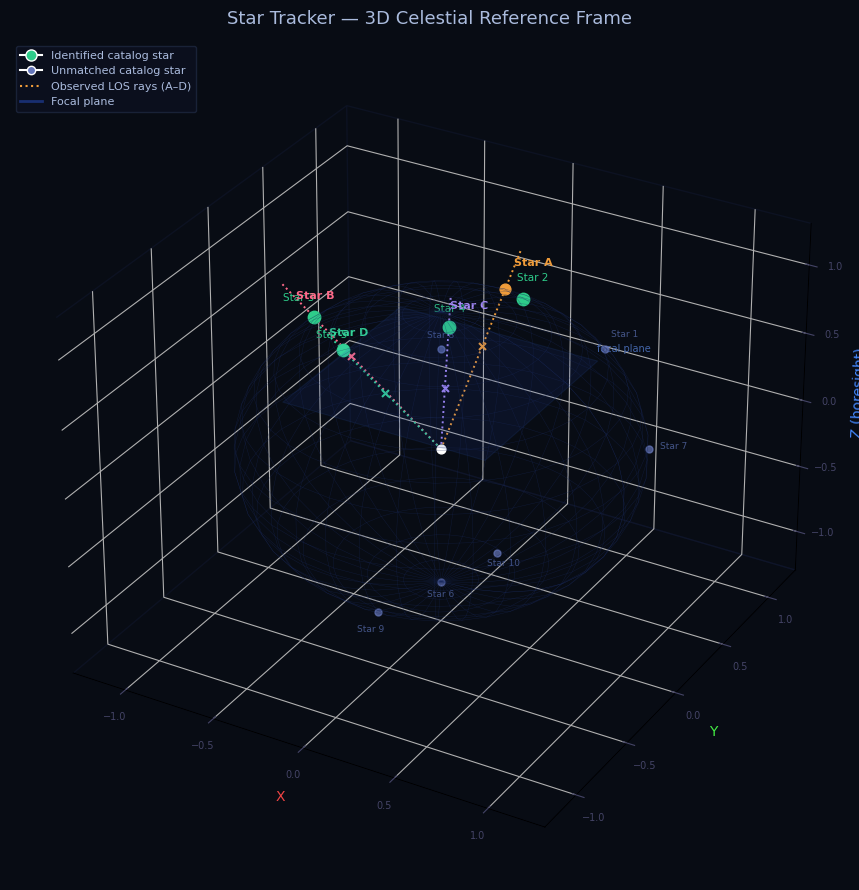

In [60]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(11, 9), facecolor='#080c14')
ax  = fig.add_subplot(111, projection='3d', facecolor='#080c14')

# 1. Unit sphere wireframe
u_ang = np.linspace(0, 2*np.pi, 36)
v_ang = np.linspace(0,   np.pi, 18)
xs = np.outer(np.cos(u_ang), np.sin(v_ang))
ys = np.outer(np.sin(u_ang), np.sin(v_ang))
zs = np.outer(np.ones_like(u_ang), np.cos(v_ang))
ax.plot_wireframe(xs, ys, zs, color='#1a2a5e', linewidth=0.3, alpha=0.5)

# 2. Catalog stars — green if matched, dim blue otherwise
matched_cat = {cat_star for cat_star, _ in assignments.values()}

for name, coords in star_catalog.items():
    cx, cy, cz = coords
    if name in matched_cat:
        ax.scatter(cx, cy, cz, color='#2ecc8a', s=80, zorder=5)
        ax.text(cx*1.12, cy*1.12, cz*1.12, name, color='#2ecc8a', fontsize=7.5, ha='center')
    else:
        ax.scatter(cx, cy, cz, color='#6677bb', s=25, alpha=0.7)
        ax.text(cx*1.12, cy*1.12, cz*1.12, name, color='#445588', fontsize=6.5, ha='center')

# 3. Focal plane at z = f_scene (scaled: sphere=1, f=50mm → f_scene=0.5)
f_scene = 0.5
hw = 0.55
corners = np.array([[-hw,-hw,f_scene],[hw,-hw,f_scene],[hw,hw,f_scene],[-hw,hw,f_scene]])
poly = Poly3DCollection([corners], alpha=0.12, facecolor='#2244aa', edgecolor='#3366cc', linewidth=0.8)
ax.add_collection3d(poly)
ax.text(hw, hw, f_scene + 0.06, 'focal plane', color='#4466aa', fontsize=7)

# 4. LOS rays — dotted from origin through sensor direction to 1.25
ray_colors = ['#f09c3a', '#ff6b8a', '#a78bfa', '#34d399']

for (star, vec), col in zip(observed_data.items(), ray_colors):
    vx, vy, vz = vec
    ax.plot([0, vx*1.25], [0, vy*1.25], [0, vz*1.25],
            color=col, linewidth=1.4, linestyle='dotted')
    ax.scatter(vx, vy, vz, color=col, s=60, zorder=6)
    ax.text(vx*1.14, vy*1.14, vz*1.14, star, color=col, fontsize=8, fontweight='bold')
    # Focal plane intersection point
    t = f_scene / vz
    ax.scatter(vx*t, vy*t, f_scene, color=col, s=25, marker='x', linewidths=1.5)

# Origin
ax.scatter(0, 0, 0, color='white', s=40, zorder=7)

# Axes style
ax.set_xlabel('X', color='#ee4444'); ax.set_ylabel('Y', color='#44ee44'); ax.set_zlabel('Z (boresight)', color='#4488ff')
ax.set_xlim(-1.3,1.3); ax.set_ylim(-1.3,1.3); ax.set_zlim(-1.3,1.3)
ax.set_title('Star Tracker — 3D Celestial Reference Frame', color='#aabbdd', fontsize=13, pad=12)
for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False; pane.set_edgecolor('#111830')
ax.tick_params(colors='#444466', labelsize=7)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc8a', markersize=8, label='Identified catalog star'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#6677bb', markersize=6, label='Unmatched catalog star'),
    Line2D([0],[0], color='#f09c3a', linewidth=1.5, linestyle='dotted', label='Observed LOS rays (A–D)'),
    Line2D([0],[0], color='#2244aa', linewidth=2, alpha=0.6, label='Focal plane'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
          facecolor='#0d1120', edgecolor='#1e2840', labelcolor='#aabbdd')

plt.tight_layout()
plt.show()